# Length Convergence

In typical RNEMD studies, they regression $\kappa$ versus $1/L$ in order to determine the "infinite-length limit $\kappa$". We do the same here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from ase.io import read

GPUMD_ROOT = Path("/gpfs/home/djr2473/PSED/gpumd")

CONFIGS = [
    "nve_xsmall",
    "nve_small",
    "nve",
    "nve_large",
]

GB_LABEL = "100_sigma13_0-32"

# --- get kappa, R_K, and length for each config ---
lengths_nm = []
kappa_means, kappa_stds = [], []
rk_means, rk_stds = [], []

for config in CONFIGS:
    # kappa and R_K from summary.csv
    summary_path = GPUMD_ROOT / "results" / config / "rnemd" / GB_LABEL / "summary.csv"
    df = pd.read_csv(summary_path)
    kappa_means.append(df["kappa_SI"].mean())
    kappa_stds.append(df["kappa_SI"].std(ddof=1))
    rk_means.append(df["R_K_SI"].mean())
    rk_stds.append(df["R_K_SI"].std(ddof=1))

    # length from structure.traj
    traj_path = GPUMD_ROOT / "results" / config / "gb_generation" / GB_LABEL / "run_0" / "structure.traj"
    atoms = read(str(traj_path))
    cell_z_nm = np.diag(atoms.cell[:])[2] / 10.0  # Å → nm
    lengths_nm.append(cell_z_nm)

lengths_nm = np.array(lengths_nm)
kappa_means = np.array(kappa_means)
kappa_stds = np.array(kappa_stds)
rk_means = np.array(rk_means)
rk_stds = np.array(rk_stds)
inv_L = 1.0 / lengths_nm

print("Config          L (nm)    1/L (nm⁻¹)    κ mean ± std (W/m·K)    R_K mean ± std (K·m²/W)")
for c, L, iL, km, ks, rm, rs in zip(CONFIGS, lengths_nm, inv_L, kappa_means, kappa_stds, rk_means, rk_stds):
    print(f"  {c:<14}  {L:7.2f}    {iL:.5f}       {km:6.3f} ± {ks:.3f}          {rm:.3e} ± {rs:.3e}")


Config          L (nm)    1/L (nm⁻¹)    κ mean ± std (W/m·K)    R_K mean ± std (K·m²/W)
  nve_xsmall        27.65    0.03617        4.701 ± 1.130          5.468e-10 ± 3.736e-10
  nve_small         51.35    0.01948        7.152 ± 1.373          2.931e-10 ± 2.743e-10
  nve              102.71    0.00974       11.942 ± 1.156          2.902e-10 ± 2.181e-10
  nve_large        201.45    0.00496        5.421 ± 0.128          6.597e-09 ± 2.604e-10


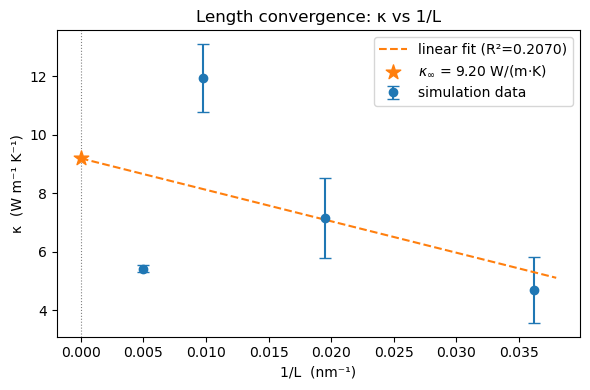


Linear fit:  κ = 9.196 + -107.596 / L
Infinite-length κ_inf = 9.196 W/(m·K)  (R² = 0.2070)


In [2]:
# --- linear fit: κ = κ_inf + m * (1/L) ---
slope, intercept, r_value, p_value, std_err = stats.linregress(inv_L, kappa_means)
kappa_inf = intercept

inv_L_fit = np.linspace(0, inv_L.max() * 1.05, 300)
kappa_fit = slope * inv_L_fit + intercept

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(inv_L, kappa_means, yerr=kappa_stds,
            fmt="o", color="C0", capsize=4, label="simulation data")
ax.plot(inv_L_fit, kappa_fit, "C1--", label=f"linear fit (R²={r_value**2:.4f})")
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.scatter([0], [kappa_inf], marker="*", s=120, color="C1", zorder=5,
           label=f"$\\kappa_{{\\infty}}$ = {kappa_inf:.2f} W/(m·K)")

ax.set_xlabel("1/L  (nm⁻¹)")
ax.set_ylabel("κ  (W m⁻¹ K⁻¹)")
ax.set_title("Length convergence: κ vs 1/L")
ax.legend()
fig.tight_layout()
plt.savefig(GPUMD_ROOT / "results" / "length_convergence.png", dpi=150)
plt.show()

print(f"\nLinear fit:  κ = {kappa_inf:.3f} + {slope:.3f} / L")
print(f"Infinite-length κ_inf = {kappa_inf:.3f} W/(m·K)  (R² = {r_value**2:.4f})")


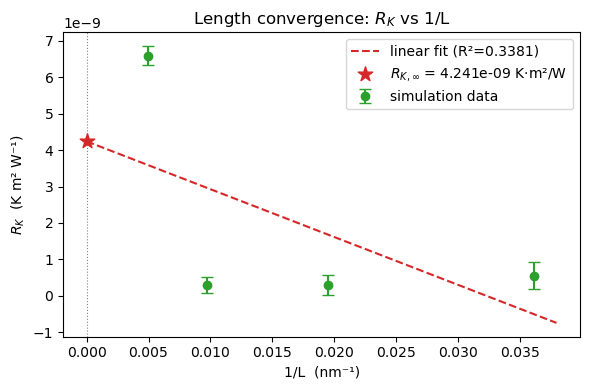


Linear fit:  R_K = 4.241e-09 + -1.313e-07 / L
Infinite-length R_K_inf = 4.241e-09 K·m²/W  (R² = 0.3381)


In [3]:
# --- R_K: linear fit and plot ---
slope_rk, intercept_rk, r_rk, _, _ = stats.linregress(inv_L, rk_means)
rk_inf = intercept_rk

inv_L_fit = np.linspace(0, inv_L.max() * 1.05, 300)
rk_fit = slope_rk * inv_L_fit + intercept_rk

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(inv_L, rk_means, yerr=rk_stds,
            fmt="o", color="C2", capsize=4, label="simulation data")
ax.plot(inv_L_fit, rk_fit, "C3--", label=f"linear fit (R²={r_rk**2:.4f})")
ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.scatter([0], [rk_inf], marker="*", s=120, color="C3", zorder=5,
           label=f"$R_{{K,\\infty}}$ = {rk_inf:.3e} K·m²/W")

ax.set_xlabel("1/L  (nm⁻¹)")
ax.set_ylabel("$R_K$  (K m² W⁻¹)")
ax.set_title("Length convergence: $R_K$ vs 1/L")
ax.legend()
fig.tight_layout()
plt.savefig(GPUMD_ROOT / "results" / "length_convergence_RK.png", dpi=150)
plt.show()

print(f"\nLinear fit:  R_K = {rk_inf:.3e} + {slope_rk:.3e} / L")
print(f"Infinite-length R_K_inf = {rk_inf:.3e} K·m²/W  (R² = {r_rk**2:.4f})")
